# Customer-Support-Intelligence-System

An explainable NLP-based customer support intelligence framework built using TF-IDF and calibrated Support Vector Machines (SVM) on a large-scale real-world Twitter customer support dataset containing over 2.8 million interactions.

The project performs customer intent classification, escalation analysis, churn-risk estimation, and retention-oriented recommendation generation using classical machine learning techniques and weak supervision.

The system emphasizes interpretability, leakage-aware feature engineering, probability calibration, and business-focused NLP analytics instead of black-box deep learning approaches.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
STOPWORDS = set(stopwords.words("english"))
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)
print("All imports loaded successfully.")

All imports loaded successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DEEP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
DATA_PATH="twcs/twcs.csv"
df=pd.read_csv(DATA_PATH)
print("Dataset Loaded Successfully")
print("\nShape:")
print(df.shape)
print("\nColumns:")
print(df.columns)
df.head()

Dataset Loaded Successfully

Shape:
(2811774, 7)

Columns:
Index(['tweet_id', 'author_id', 'inbound', 'created_at', 'text',
       'response_tweet_id', 'in_response_to_tweet_id'],
      dtype='object')


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [3]:
print("Columns:")
print(df.columns)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Info:")
print(df.info())
print("\nSample Text:")
print(df["text"].head(5).values)

Columns:
Index(['tweet_id', 'author_id', 'inbound', 'created_at', 'text',
       'response_tweet_id', 'in_response_to_tweet_id'],
      dtype='object')

Missing Values:
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 7 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tweet_id                 int64  
 1   author_id                object 
 2   inbound                  bool   
 3   created_at               object 
 4   text                     object 
 5   response_tweet_id        object 
 6   in_response_to_tweet_id  float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 131.4+ MB
None

Sample Text:
['@115712 I 

In [4]:
df=df[df["inbound"]==True].copy()
print("Shape after filtering inbound messages:")
print(df.shape)
df=df[["text"]].dropna()
df.head()

Shape after filtering inbound messages:
(1537843, 7)


,text
1,@sprintcare and how do you propose we do that
2,@sprintcare I have sent several private messag...
4,@sprintcare I did.
6,@sprintcare is the worst customer service
8,@sprintcare You gonna magically change your co...


In [5]:
def clean_text(text):
    text=str(text).lower()
    text=re.sub(r"http\S+","",text)
    text=re.sub(r"@\w+","",text)
    text=re.sub(r"\d+","",text)
    text=text.translate(
        str.maketrans("","",string.punctuation)
    )
    text=re.sub(r"\s+"," ",text).strip()
    words = [
        word for word in text.split()
        if word not in STOPWORDS
    ]
    return " ".join(words)
print("Cleaning text...")
df["clean_text"]=df["text"].apply(clean_text)
df.head()

Cleaning text...


,text,clean_text
1,@sprintcare and how do you propose we do that,propose
2,@sprintcare I have sent several private messag...,sent several private messages one responding u...
4,@sprintcare I did.,
6,@sprintcare is the worst customer service,worst customer service
8,@sprintcare You gonna magically change your co...,gonna magically change connectivity whole fami...


In [6]:
NEGOTIATION_WORDS=[
    "discount","cheaper","offer","deal",
    "promo","coupon","expensive","price",
    "sale","better price"
]

REFUND_WORDS=[
    "refund","money back","return",
    "cancel","cancelled","charged twice"
]
SHIPPING_WORDS=[
    "delivery","shipping","late",
    "tracking","arrive","courier",
    "package","delivered"
]
COMPLAINT_WORDS=[
    "bad","worst","terrible","broken",
    "issue","problem","hate","angry",
    "frustrated","poor service"
]
POSITIVE_WORDS=[
    "thanks","great","awesome",
    "love","perfect","excellent",
    "amazing","good service"
]


def assign_label(text):
    text=str(text).lower()
    scores={
        "negotiation":0,
        "refund":0,
        "shipping":0,
        "complaint":0,
        "positive":0
    }

    for word in NEGOTIATION_WORDS:
        if word in text:
            scores["negotiation"]+=1

    for word in REFUND_WORDS:
        if word in text:
            scores["refund"]+=1

    for word in SHIPPING_WORDS:
        if word in text:
            scores["shipping"]+=1

    for word in COMPLAINT_WORDS:
        if word in text:
            scores["complaint"]+=1

    for word in POSITIVE_WORDS:
        if word in text:
            scores["positive"]+=1

    best_label=max(scores,key=scores.get)

    if scores[best_label]==0:
        return "other"

    return best_label

df["label"]=df["clean_text"].apply(assign_label)

print("="*50)
print("LABEL DISTRIBUTION")
print("="*50)

print(df["label"].value_counts())

print("\nPercentage Distribution:")
print(
    (
        df["label"].value_counts(normalize=True) * 100
    ).round(2)
)

LABEL DISTRIBUTION
label
other          1088447
complaint       119614
positive        114360
shipping         94717
refund           67620
negotiation      53085
Name: count, dtype: int64

Percentage Distribution:
label
other          70.78
complaint       7.78
positive        7.44
shipping        6.16
refund          4.40
negotiation     3.45
Name: proportion, dtype: float64


In [7]:
df=df[df["label"]!="other"]
print(df["label"].value_counts())

print("\nFinal Shape:")
print(df.shape)

assert len(df) > 0, "Dataset became empty!"

label
complaint      119614
positive       114360
shipping        94717
refund          67620
negotiation     53085
Name: count, dtype: int64

Final Shape:
(449396, 3)


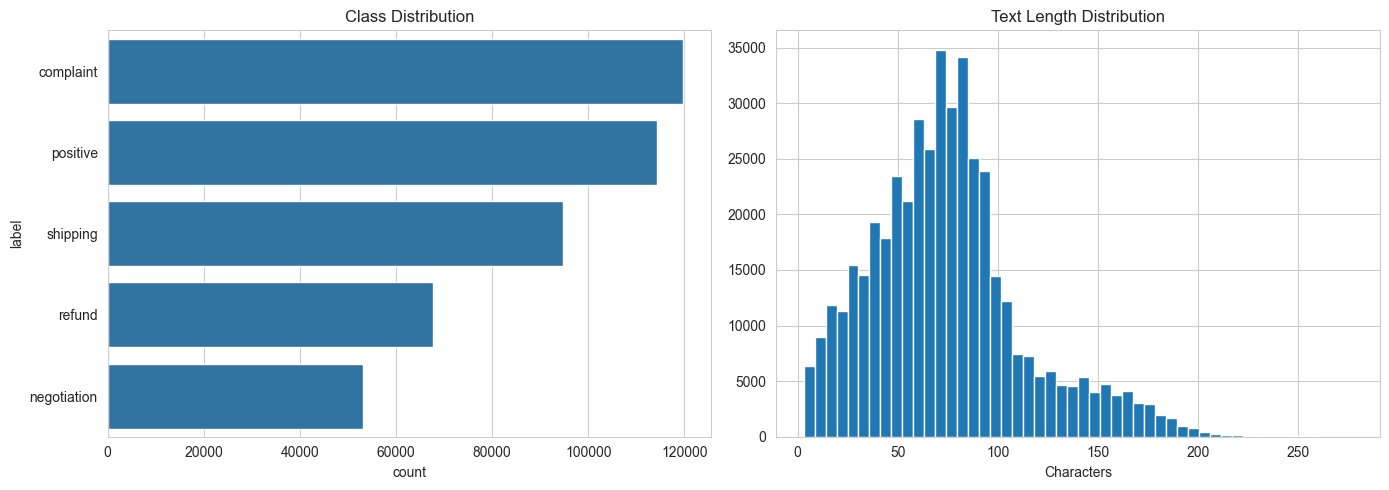

In [8]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.countplot(
    y=df["label"],
    order=df["label"].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Class Distribution")

df["text_length"]=df["clean_text"].apply(len)

axes[1].hist(
    df["text_length"],
    bins=50,
    edgecolor="white"
)

axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

In [9]:
X=df["clean_text"]
y=df["label"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:",X_train.shape)
print("Test Shape :",X_test.shape)

Train Shape: (359516,)
Test Shape : (89880,)


In [10]:
print(df["label"].value_counts())

label
complaint      119614
positive       114360
shipping        94717
refund          67620
negotiation     53085
Name: count, dtype: int64


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
print("Reducing direct keyword leakage...")

LEAKAGE_WORDS=[
    "refund",
    "discount",
    "shipping",
    "delivery",
    "coupon",
    "promo",
    "deal",
    "offer",
    "cancel",
    "return"
]

def reduce_leakage(text):
    text=str(text)
    for word in LEAKAGE_WORDS:
        text=re.sub(
            rf"\b{word}\b",
            "",
            text,
            flags=re.IGNORECASE
        )
    return text

X_train_clean=X_train.apply(reduce_leakage)
X_test_clean=X_test.apply(reduce_leakage)

tfidf=TfidfVectorizer(
    max_features=25000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

X_train_tfidf=tfidf.fit_transform(
    X_train_clean
)
X_test_tfidf=tfidf.transform(
    X_test_clean
)
print("TF-IDF completed.")
print("\nTrain Shape:")
print(X_train_tfidf.shape)
print("\nTest Shape:")
print(X_test_tfidf.shape)

Reducing direct keyword leakage...
TF-IDF completed.

Train Shape:
(359516, 25000)

Test Shape:
(89880, 25000)


In [12]:
from sklearn.linear_model import LogisticRegression
print("Training Logistic Regression...")

log_model=LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

log_model.fit(X_train_tfidf, y_train)
print("Training completed.")

Training Logistic Regression...
Training completed.


LOGISTIC REGRESSION RESULTS

Accuracy Score:0.9069
Weighted F1:0.9069

Classification Report:

              precision    recall  f1-score   support

   complaint       0.95      0.96      0.95     23923
 negotiation       0.82      0.82      0.82     10617
    positive       0.96      0.97      0.96     22872
      refund       0.81      0.82      0.81     13524
    shipping       0.92      0.88      0.90     18944

    accuracy                           0.91     89880
   macro avg       0.89      0.89      0.89     89880
weighted avg       0.91      0.91      0.91     89880



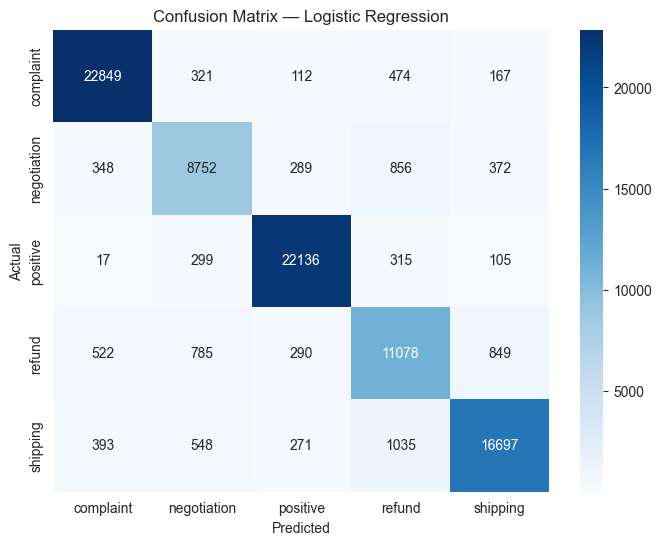

In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
y_pred=log_model.predict(X_test_tfidf)
acc=accuracy_score(y_test, y_pred)

f1=f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*55)
print("LOGISTIC REGRESSION RESULTS")
print("="*55)

print(f"\nAccuracy Score:{acc:.4f}")
print(f"Weighted F1:{f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)

plt.title("Confusion Matrix — Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [14]:
from sklearn.svm import LinearSVC
print("Training Linear SVM...")
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)
svm_model.fit(X_train_tfidf, y_train)
print("Training completed.")

Training Linear SVM...
Training completed.


LINEAR SVM RESULTS

Accuracy Score:0.9101
Weighted F1    :0.9095

Classification Report:

              precision    recall  f1-score   support

   complaint       0.94      0.96      0.95     23923
 negotiation       0.85      0.81      0.83     10617
    positive       0.95      0.97      0.96     22872
      refund       0.82      0.81      0.81     13524
    shipping       0.91      0.89      0.90     18944

    accuracy                           0.91     89880
   macro avg       0.90      0.89      0.89     89880
weighted avg       0.91      0.91      0.91     89880



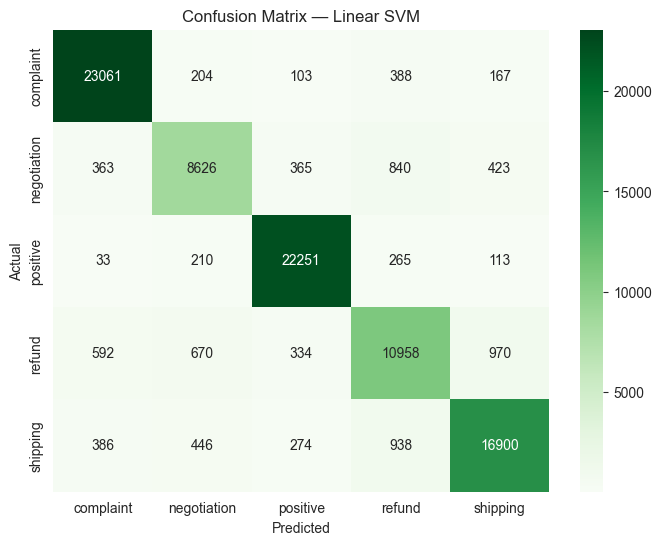

In [15]:
svm_pred=svm_model.predict(X_test_tfidf)

svm_acc=accuracy_score(y_test,svm_pred)

svm_f1=f1_score(
    y_test,
    svm_pred,
    average="weighted"
)

print("="*55)
print("LINEAR SVM RESULTS")
print("="*55)
print(f"\nAccuracy Score:{svm_acc:.4f}")

print(f"Weighted F1    :{svm_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test,svm_pred))

svm_cm=confusion_matrix(y_test,svm_pred)
plt.figure(figsize=(8,6))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)

plt.title("Confusion Matrix — Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

                 Model  Accuracy  Weighted F1
1           Linear SVM  0.910058     0.909504
0  Logistic Regression  0.906898     0.906910


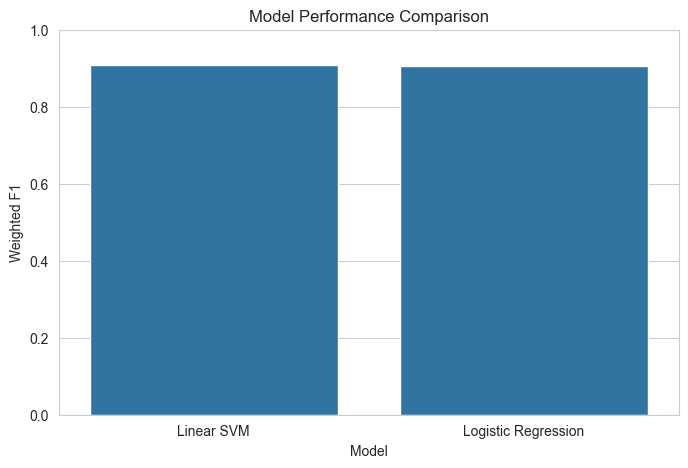

In [17]:
comparison=pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy":[
        acc,
        svm_acc
    ],

    "Weighted F1":[
        f1,
        svm_f1
    ]
})

comparison=comparison.sort_values(
    "Weighted F1",
    ascending=False
)

print(comparison)
plt.figure(figsize=(8,5))
sns.barplot(
    data=comparison,
    x="Model",
    y="Weighted F1"
)
plt.title("Model Performance Comparison")
plt.ylim(0,1)
plt.show()

In [18]:
sample_messages=[
    "This product is too expensive can I get a discount",
    "My package still has not arrived",
    "I want a refund immediately",
    "Thank you for the amazing support",
    "Your service is terrible and frustrating"
]

cleaned_messages=[
    clean_text(msg)
    for msg in sample_messages
]

sample_vectors=tfidf.transform(cleaned_messages)

sample_preds=svm_model.predict(sample_vectors)

print("="*60)
print("CUSTOMER MESSAGE PREDICTIONS")
print("="*60)

for text, pred in zip(sample_messages, sample_preds):
    print("\nMESSAGE:")
    print(text)
    print("PREDICTED LABEL:")
    print(pred)

    print("-"*60)

CUSTOMER MESSAGE PREDICTIONS

MESSAGE:
This product is too expensive can I get a discount
PREDICTED LABEL:
negotiation
------------------------------------------------------------

MESSAGE:
My package still has not arrived
PREDICTED LABEL:
shipping
------------------------------------------------------------

MESSAGE:
I want a refund immediately
PREDICTED LABEL:
refund
------------------------------------------------------------

MESSAGE:
Thank you for the amazing support
PREDICTED LABEL:
positive
------------------------------------------------------------

MESSAGE:
Your service is terrible and frustrating
PREDICTED LABEL:
complaint
------------------------------------------------------------


In [19]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
print("Training calibrated SVM model...")

base_svm=LinearSVC(
    class_weight="balanced",
    random_state=42
)

calibrated_svm=CalibratedClassifierCV(
    estimator=base_svm,
    cv=3
)

calibrated_svm.fit(
    X_train_tfidf,
    y_train
)

print("Training completed.")

Training calibrated SVM model...
Training completed.


In [20]:
cal_pred=calibrated_svm.predict(X_test_tfidf)
cal_acc=accuracy_score(y_test, cal_pred)
cal_f1 = f1_score(
    y_test,
    cal_pred,
    average="weighted"
)

print("="*60)
print(" CALIBRATED SVM RESULTS")
print("="*60)

print(f"\nAccuracy Score:{cal_acc:.4f}")
print(f"Weighted F1    : {cal_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test,cal_pred))

 CALIBRATED SVM RESULTS

Accuracy Score:0.9118
Weighted F1    : 0.9109

Classification Report:

              precision    recall  f1-score   support

   complaint       0.94      0.97      0.95     23923
 negotiation       0.88      0.79      0.84     10617
    positive       0.95      0.98      0.96     22872
      refund       0.83      0.81      0.82     13524
    shipping       0.90      0.90      0.90     18944

    accuracy                           0.91     89880
   macro avg       0.90      0.89      0.89     89880
weighted avg       0.91      0.91      0.91     89880



In [21]:
feature_names=tfidf.get_feature_names_out()
classes=svm_model.classes_
print("="*60)
print("TOP KEYWORDS PER CLASS")
print("="*60)

for i, label in enumerate(classes):
    print(f"\nCLASS:{label.upper()}")
    top_idx=np.argsort(
        svm_model.coef_[i]
    )[-15:]
    top_words=feature_names[top_idx]
    print(",".join(top_words))

TOP KEYWORDS PER CLASS

CLASS:COMPLAINT
poor service,badly,problema,angry,whatever,frustrated,broken,hate,terrible,worst,problems,bad,issues,issue,problem

CLASS:NEGOTIATION
overpriced,ideal,offering,promotion,deals,cheaper,dealt,offers,prices,dealing,sales,offered,sale,expensive,price

CLASS:POSITIVE
greater,good service,loves,greatly,thanksgiving,perfectly,lovely,loved,excellent,perfect,amazing,awesome,great,love,thanks

CLASS:REFUND
delayedcancelled,refunds,cancels,refunding,returns,money back,canceling,refunded,cancellations,cancelling,returning,cancellation,canceled,returned,cancelled

CLASS:SHIPPING
escalate,isolated,escalated,chocolate,packages,tracking,lately,arrive,related,arrived,delivered,package,latest,later,late


In [22]:
def recommendation_engine(message):
    cleaned=clean_text(message)
    vec=tfidf.transform([cleaned])
    pred=calibrated_svm.predict(vec)[0]
    probs=calibrated_svm.predict_proba(vec)[0]
    labels=calibrated_svm.classes_

    prob_dict={
        label:round(prob*100,2)
        for label,prob in zip(labels,probs)
    }

    frustration_words=[
        "angry",
        "worst",
        "terrible",
        "hate",
        "frustrated",
        "bad",
        "awful",
        "poor"
    ]

    frustration_score=0
    for word in frustration_words:
        if word in cleaned:
            frustration_score +=1

    escalation_risk=min(
        100,
        round(
            (
                prob_dict.get("complaint",0)*0.6
                +
                frustration_score*15
            ),
            2
        )
    )

    recommendation="No action required"

    if pred=="negotiation":
        if prob_dict["negotiation"]>90:
            recommendation="Offer 15% discount"

        elif prob_dict["negotiation"]>75:
            recommendation="Offer 10% discount"

        else:
            recommendation="Offer 5% coupon"

    elif pred=="refund":
        recommendation=(
            "Escalate to retention team "
            "+ offer loyalty coupon"
        )
    elif pred=="complaint":

        if escalation_risk>70:
            recommendation=(
                "Priority escalation to senior support"
            )
        else:
            recommendation=(
                "Assign high-priority support ticket"
            )

    elif pred=="shipping":

        recommendation=(
            "Provide live tracking support"
        )

    elif pred=="positive":

        recommendation=(
            "Upsell premium membership/products"
        )
    print("="*65)
    print("CUSTOMER MESSAGE:")
    print(message)

    print("\nPREDICTED INTENT:")
    print(pred)

    print("\nESCALATION RISK:")
    print(f"{escalation_risk}%")

    print("\nCLASS PROBABILITIES:")
    
    for k,v in prob_dict.items():
        print(f"{k:15}:{v}%")

    print("\nRECOMMENDED ACTION:")
    print(recommendation)

    print("="*65)

In [23]:
test_messages=[
    "This product is too expensive can you lower the price",
    "I am extremely frustrated with your terrible service",
    "I want a refund immediately",
    "My package is delayed again",
    "Thank you for the excellent support",
    "Can you provide a better deal if I buy two items",
    "Worst customer support experience ever",
    "Your delivery service is awful and late"
]
for msg in test_messages:
    recommendation_engine(msg)

CUSTOMER MESSAGE:
This product is too expensive can you lower the price

PREDICTED INTENT:
negotiation

ESCALATION RISK:
0.0%

CLASS PROBABILITIES:
complaint      :0.0%
negotiation    :100.0%
positive       :0.0%
refund         :0.0%
shipping       :0.0%

RECOMMENDED ACTION:
Offer 15% discount
CUSTOMER MESSAGE:
I am extremely frustrated with your terrible service

PREDICTED INTENT:
complaint

ESCALATION RISK:
89.87%

CLASS PROBABILITIES:
complaint      :99.79%
negotiation    :0.09%
positive       :0.0%
refund         :0.01%
shipping       :0.1%

RECOMMENDED ACTION:
Priority escalation to senior support
CUSTOMER MESSAGE:
I want a refund immediately

PREDICTED INTENT:
refund

ESCALATION RISK:
0.09%

CLASS PROBABILITIES:
complaint      :0.15%
negotiation    :2.88%
positive       :0.44%
refund         :96.08%
shipping       :0.45%

RECOMMENDED ACTION:
Escalate to retention team + offer loyalty coupon
CUSTOMER MESSAGE:
My package is delayed again

PREDICTED INTENT:
shipping

ESCALATION RISK

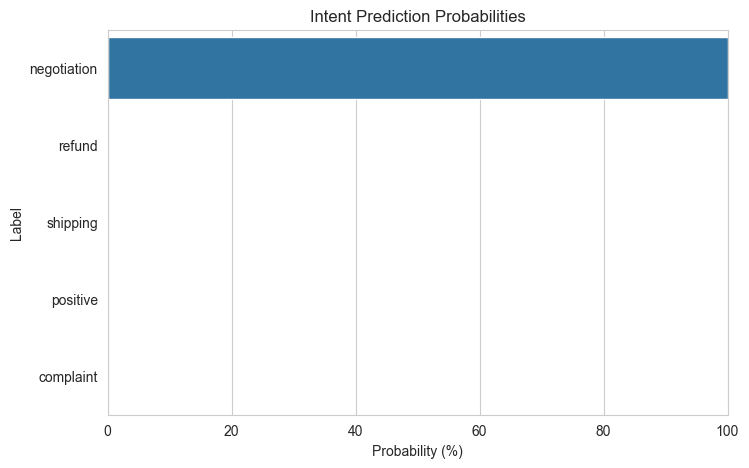

In [24]:
sample_text=(
    "This item is too expensive "
    "can you give me a discount"
)
cleaned=clean_text(sample_text)
vec=tfidf.transform([cleaned])
probs=calibrated_svm.predict_proba(vec)[0]
labels=calibrated_svm.classes_

prob_df=pd.DataFrame({
    "Label":labels,
    "Probability":probs*100
})
prob_df=prob_df.sort_values(
    "Probability",
    ascending=False
)
plt.figure(figsize=(8,5))
sns.barplot(
    data=prob_df,
    x="Probability",
    y="Label"
)
plt.title("Intent Prediction Probabilities")
plt.xlabel("Probability (%)")
plt.xlim(0, 100)
plt.show()

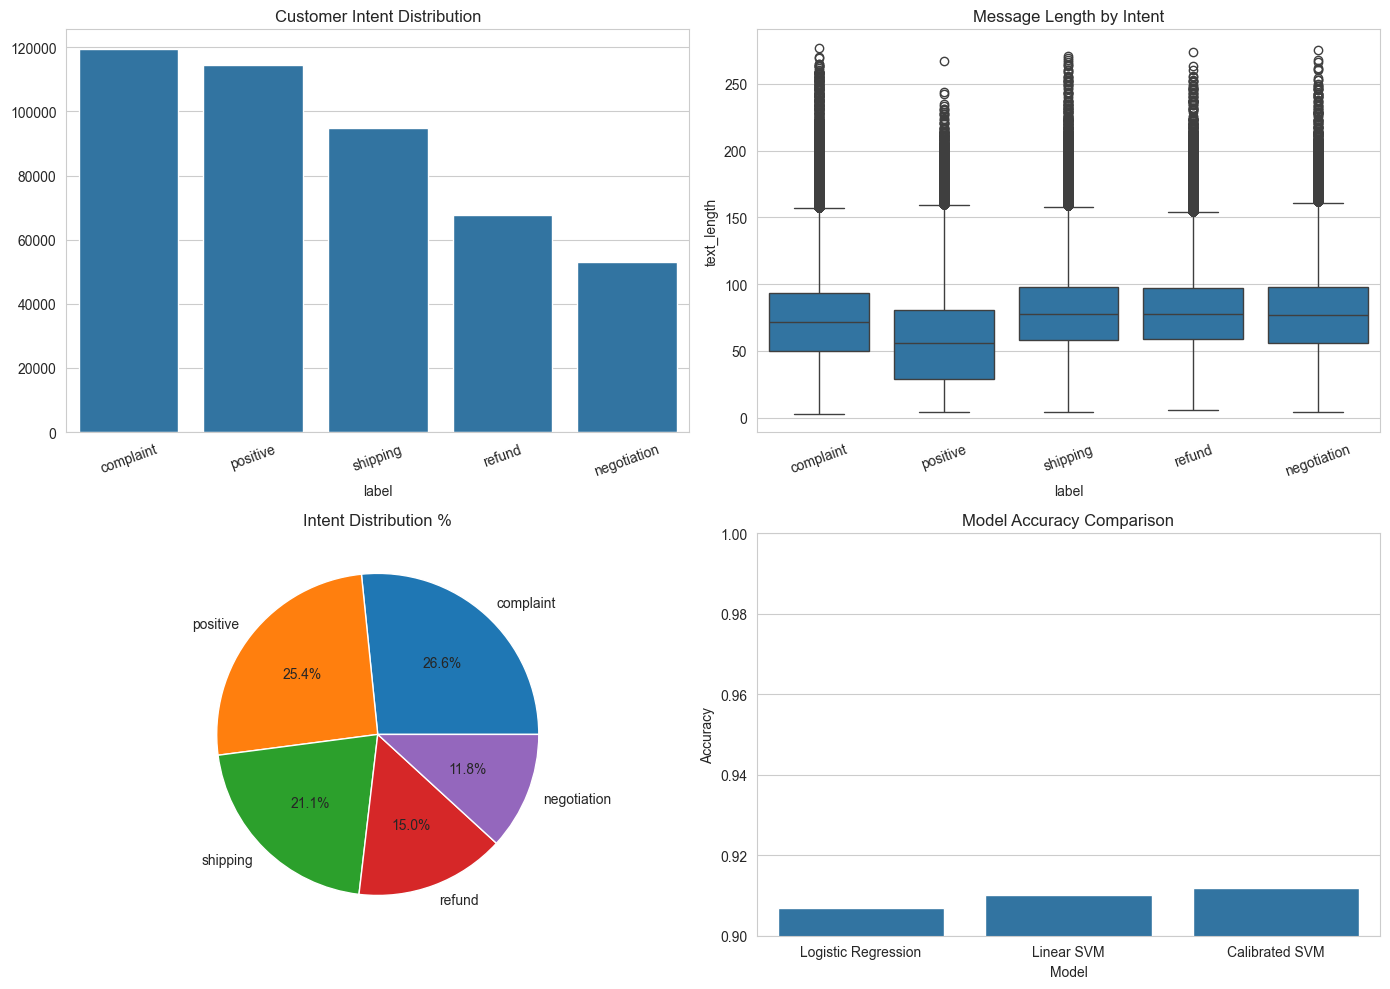

In [25]:
label_counts=df["label"].value_counts()
fig,axes=plt.subplots(
    2,
    2,
    figsize=(14,10)
)

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    ax=axes[0,0]
)
axes[0,0].set_title("Customer Intent Distribution")
axes[0,0].tick_params(axis='x',rotation=20)

df["text_length"]=(
    df["clean_text"]
    .apply(len)
)
sns.boxplot(
    data=df,
    x="label",
    y="text_length",
    ax=axes[0,1]
)
axes[0,1].set_title("Message Length by Intent")
axes[0,1].tick_params(axis='x', rotation=20)

intent_pct=(
    df["label"]
    .value_counts(normalize=True)
    *100
)

axes[1,0].pie(
    intent_pct.values,
    labels=intent_pct.index,
    autopct="%1.1f%%"
)

axes[1,0].set_title("Intent Distribution %")

perf_df=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Linear SVM",
        "Calibrated SVM"
    ],
    "Accuracy":[
        acc,
        svm_acc,
        cal_acc
    ]
})

sns.barplot(
    data=perf_df,
    x="Model",
    y="Accuracy",
    ax=axes[1,1]
)

axes[1,1].set_ylim(0.9, 1.0)

axes[1,1].set_title("Model Accuracy Comparison")

plt.tight_layout()

plt.show()

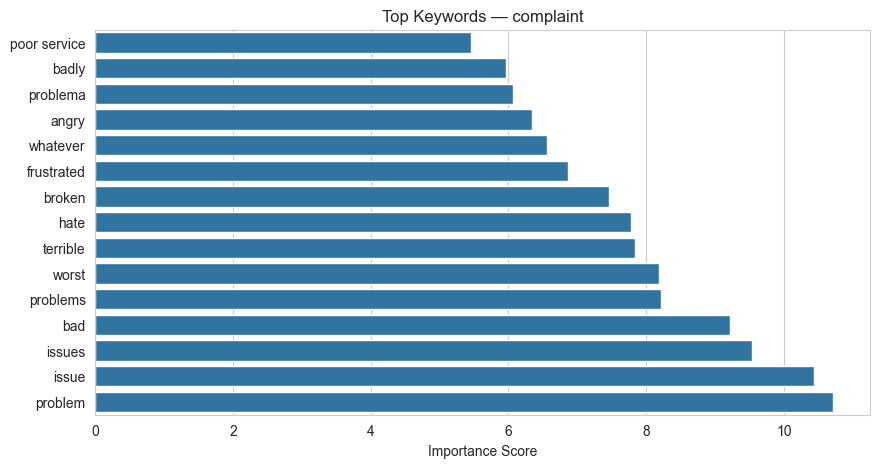

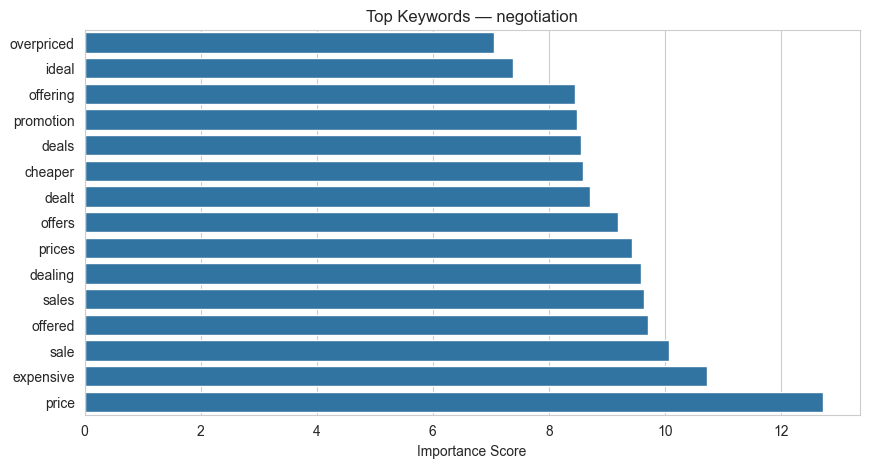

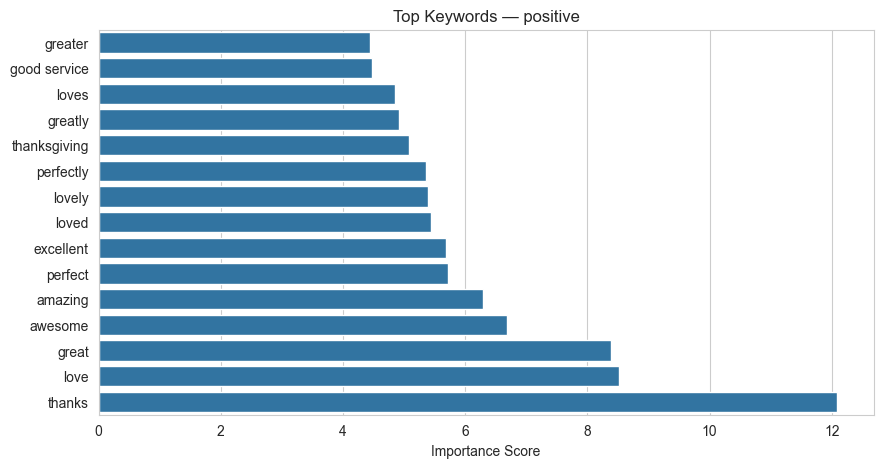

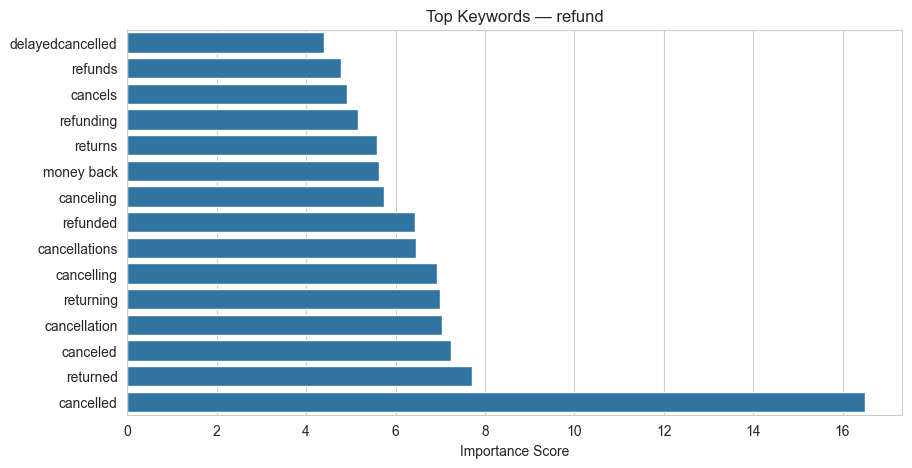

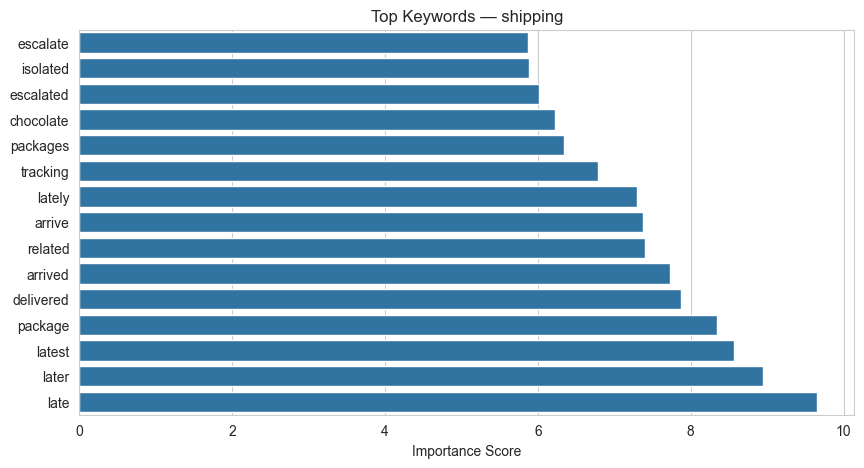

In [26]:
feature_names=tfidf.get_feature_names_out()
classes=svm_model.classes_

for i,label in enumerate(classes):
    coef=svm_model.coef_[i]
    top_idx=np.argsort(coef)[-15:]
    top_words=feature_names[top_idx]
    top_scores=coef[top_idx]
    plt.figure(figsize=(10,5))

    sns.barplot(
        x=top_scores,
        y=top_words
    )
    plt.title(f"Top Keywords — {label}")
    plt.xlabel("Importance Score")
    plt.show()

In [28]:
def risk_score_engine_v2(message):
    cleaned=clean_text(message)
    vec=tfidf.transform([cleaned])
    probs=calibrated_svm.predict_proba(vec)[0]

    labels=calibrated_svm.classes_

    prob_dict={
        label: prob
        for label, prob in zip(labels, probs)
    }

    frustration_words=[
        "angry",
        "worst",
        "terrible",
        "hate",
        "frustrated",
        "awful",
        "bad",
        "disappointed",
        "ridiculous",
        "horrible"
    ]

    frustration_score=0
    for word in frustration_words:
        if word in cleaned:
            frustration_score+=1

    repeat_issue_words=[
        "again",
        "still",
        "multiple",
        "many times",
        "repeated",
        "already",
        "yet"
    ]
    repeat_score=0

    for word in repeat_issue_words:
        if word in cleaned:
            repeat_score +=1

    churn_risk=(
    prob_dict.get("complaint", 0)*45
    +
    prob_dict.get("refund", 0)*65
    +
    prob_dict.get("shipping", 0)*30
    +
    prob_dict.get("negotiation", 0)*15
    +
    frustration_score*12
    +
    repeat_score*10
)
    churn_risk=round(
        min(churn_risk,100),
        2
    )

    if churn_risk>=75:
        category="HIGH RISK"

    elif churn_risk>=40:
        category="MEDIUM RISK"
    else:
        category="LOW RISK"
 
    if category=="HIGH RISK":
        retention_action=(
            "Immediate senior escalation + compensation"
        )

    elif category=="MEDIUM RISK":
        retention_action=(
            "Priority support + retention follow-up"
        )
    else:
        retention_action=(
            "Standard automated handling"
        )

    predicted_intent=max(
        prob_dict,
        key=prob_dict.get
    )
    print("="*65)

    print("CUSTOMER MESSAGE:")
    print(message)

    print("\nPREDICTED INTENT:")
    print(predicted_intent)

    print("\nCHURN RISK SCORE:")
    print(f"{churn_risk}%")

    print("\nRISK CATEGORY:")
    print(category)

    print("\nRETENTION ACTION:")
    print(retention_action)

    print("\nCLASS PROBABILITIES:")

    for k,v in prob_dict.items():
        print(f"{k:15}:{round(v*100,2)}%")
    print("="*65)

In [29]:
test_cases = [
    "My order is delayed again and I am frustrated",
    "Worst customer experience ever",
    "I want a refund immediately",
    "Can you give me a better deal",
    "Thank you for the excellent support",
    "Your delivery service is terrible and still not fixed",
    "I am angry because my package is late again",
    "This is the worst support experience ever"
]
for msg in test_cases:
    risk_score_engine_v2(msg)

CUSTOMER MESSAGE:
My order is delayed again and I am frustrated

PREDICTED INTENT:
complaint

CHURN RISK SCORE:
56.4%

RISK CATEGORY:
MEDIUM RISK

RETENTION ACTION:
Priority support + retention follow-up

CLASS PROBABILITIES:
complaint      :94.73%
negotiation    :0.1%
positive       :0.0%
refund         :0.58%
shipping       :4.6%
CUSTOMER MESSAGE:
Worst customer experience ever

PREDICTED INTENT:
complaint

CHURN RISK SCORE:
56.75%

RISK CATEGORY:
MEDIUM RISK

RETENTION ACTION:
Priority support + retention follow-up

CLASS PROBABILITIES:
complaint      :97.57%
negotiation    :0.93%
positive       :0.0%
refund         :0.72%
shipping       :0.78%
CUSTOMER MESSAGE:
I want a refund immediately

PREDICTED INTENT:
refund

CHURN RISK SCORE:
63.09%

RISK CATEGORY:
MEDIUM RISK

RETENTION ACTION:
Priority support + retention follow-up

CLASS PROBABILITIES:
complaint      :0.15%
negotiation    :2.88%
positive       :0.44%
refund         :96.08%
shipping       :0.45%
CUSTOMER MESSAGE:
Can you g

In [30]:
import joblib

joblib.dump(
    svm_model,
    "linear_svm_model.pkl"
)

joblib.dump(
    calibrated_svm,
    "calibrated_svm_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("Models saved successfully.")

Models saved successfully.


In [31]:
loaded_svm=joblib.load(
    "linear_svm_model.pkl"
)

loaded_calibrated=joblib.load(
    "calibrated_svm_model.pkl"
)

loaded_tfidf=joblib.load(
    "tfidf_vectorizer.pkl"
)

print("Models loaded successfully.")

Models loaded successfully.


In [32]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

final_preds=calibrated_svm.predict(
    X_test_tfidf
)

final_accuracy=accuracy_score(
    y_test,
    final_preds
)

final_f1=f1_score(
    y_test,
    final_preds,
    average="weighted"
)

report=classification_report(
    y_test,
    final_preds
)

print("="*60)
print(" FINAL MODEL EVALUATION ")
print("="*60)

print(f"\nAccuracy Score:{final_accuracy:.4f}")
print(f"Weighted F1    :{final_f1:.4f}")
print("\nClassification Report:\n")
print(report)

 FINAL MODEL EVALUATION 

Accuracy Score:0.9118
Weighted F1    :0.9109

Classification Report:

              precision    recall  f1-score   support

   complaint       0.94      0.97      0.95     23923
 negotiation       0.88      0.79      0.84     10617
    positive       0.95      0.98      0.96     22872
      refund       0.83      0.81      0.82     13524
    shipping       0.90      0.90      0.90     18944

    accuracy                           0.91     89880
   macro avg       0.90      0.89      0.89     89880
weighted avg       0.91      0.91      0.91     89880

